# NB20 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of
`NB20_Case_Study_GMRT_Bathymetry_Interpolation.ipynb`:

1. Repeat Section 8's density experiment with Random Forest instead of kNN -- does the same accuracy-vs-density relationship hold, or does one method need less data than the other to reach a given RMSE?
2. Change `n_neighbors` in Section 7's kNN model (try 1, 3, 8, 30) at a fixed survey fraction -- plot RMSE against `k` and connect the result back to Section 6's local-detail-vs-smoothing trade-off.
3. Instead of a uniformly-random "survey," simulate a real line-survey pattern (e.g. keep only points within a fixed distance of a few straight north-south lines) at the same overall point count as one of Section 8's fractions -- does interpolation accuracy get worse, matching the Section 9 caveat about line surveys being harder than random sampling?
4. Request a GMRT grid for a different real coastal area (change the bounding box in Section 3) and re-run the full notebook -- does the accuracy-vs-density curve look similar, or does local seafloor terrain (a steep shelf edge vs. a gentle slope) change the relationship?
5. Add `elevation_m > 0` (land) points back into a combined interpolation task -- does mixing land and sea points help or hurt predicting depth near the coastline, where the two regimes meet?

GMRT's GridServer needs no login, so every item below was run against a real,
freshly-downloaded bathymetry grid (no mirrors, no placeholders). The setup
section below re-creates the class notebook's Sections 3-7 data pipeline
(download, parse the Esri ASCII grid, split sea/land, simulate a sparse survey)
so each homework item has the same real data and conventions to build on.

## Setup: reproducing the class's data pipeline

Same GMRT request, same Esri ASCII parsing, same sea/land split and the same
`SURVEY_FRACTION = 0.02` sparse-survey simulation as the class notebook's
Sections 3-7, with `random_state=42` throughout as the parent notebook uses.

In [1]:
import urllib.request
import os
import numpy as np
import pandas as pd

GMRT_URL = (
    "https://www.gmrt.org/services/GridServer"
    "?minlongitude=-1.6&maxlongitude=-0.6"
    "&minlatitude=37.3&maxlatitude=37.8"
    "&format=esriascii&resolution=low"
)

grid_path = "cartagena_bathymetry.asc"
if not os.path.exists(grid_path):
    urllib.request.urlretrieve(GMRT_URL, grid_path)

print(f"Downloaded {os.path.getsize(grid_path) / 1e6:.1f} MB to {grid_path}")

Downloaded 3.1 MB to cartagena_bathymetry.asc


Parse the ESRI ASCII grid header (rows, columns, cell size, nodata value) and load the elevation grid itself:

In [2]:
with open(grid_path) as f:
    header = {}
    for _ in range(6):
        key, val = f.readline().split()
        header[key.lower()] = val
    ncols = int(header["ncols"])
    nrows = int(header["nrows"])
    xllcorner = float(header["xllcorner"])
    yllcorner = float(header["yllcorner"])
    cellsize = float(header["cellsize"])
    nodata_value = float(header["nodata_value"])
    grid = np.loadtxt(f)

assert grid.shape == (nrows, ncols), f"Unexpected grid shape {grid.shape}, expected ({nrows}, {ncols})"
print(f"Grid shape: {grid.shape} (rows x cols), cell size ~{cellsize * 111_000:.0f} m")

Grid shape: (456, 911) (rows x cols), cell size ~122 m


Convert the raw grid into a long-format DataFrame of longitude, latitude, and elevation, then split it into sea (depth) versus land points:

In [3]:
lons = xllcorner + cellsize * np.arange(ncols)
lats = yllcorner + cellsize * np.arange(nrows)[::-1]  # first row = northernmost
lon_grid, lat_grid = np.meshgrid(lons, lats)

bathy = pd.DataFrame({
    "longitude": lon_grid.ravel(),
    "latitude": lat_grid.ravel(),
    "elevation_m": grid.ravel(),
})
bathy = bathy[bathy["elevation_m"] != nodata_value].reset_index(drop=True)

sea = bathy[bathy["elevation_m"] <= 0].copy()
sea["depth_m"] = -sea["elevation_m"]
land = bathy[bathy["elevation_m"] > 0]

print(f"{len(bathy):,} valid cells -- sea: {len(sea):,} ({len(sea)/len(bathy):.1%}), land: {len(land):,} ({len(land)/len(bathy):.1%})")

415,416 valid cells -- sea: 239,030 (57.5%), land: 176,386 (42.5%)


Simulate a real hydrographic survey by randomly sampling 2% of sea cells as 'known' soundings and holding out the rest as ground truth:

In [4]:
from sklearn.model_selection import train_test_split

SURVEY_FRACTION = 0.02  # same fixed density the class used in Section 5

known, unknown = train_test_split(sea, train_size=SURVEY_FRACTION, random_state=42)
X_known, y_known = known[["longitude", "latitude"]], known["depth_m"]
X_unknown, y_unknown = unknown[["longitude", "latitude"]], unknown["depth_m"]

print(f"Simulated survey: {len(known):,} known soundings ({SURVEY_FRACTION:.1%} of all sea cells)")
print(f"Held out: {len(unknown):,} real depth values the model never trains on")

Simulated survey: 4,780 known soundings (2.0% of all sea cells)
Held out: 234,250 real depth values the model never trains on


## Homework 1 — Density experiment with Random Forest instead of kNN

> "Repeat Section 8's density experiment with Random Forest instead of kNN --
> does the same accuracy-vs-density relationship hold, or does one method need
> less data than the other to reach a given RMSE?"

Same `fractions` list and the same `train_test_split(sea, train_size=frac,
random_state=42)` convention as Section 8, swapping `KNeighborsRegressor` for
`RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)` (the
exact Random Forest settings Section 7 already used for the single-fraction
comparison).

In [5]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

fractions = [0.002, 0.005, 0.01, 0.02, 0.05, 0.10]
density_results = []

for frac in fractions:
    known_f, unknown_f = train_test_split(sea, train_size=frac, random_state=42)

    knn = KNeighborsRegressor(n_neighbors=8, weights="distance")
    knn.fit(known_f[["longitude", "latitude"]], known_f["depth_m"])
    rmse_knn = mean_squared_error(unknown_f["depth_m"], knn.predict(unknown_f[["longitude", "latitude"]])) ** 0.5

    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(known_f[["longitude", "latitude"]], known_f["depth_m"])
    rmse_rf = mean_squared_error(unknown_f["depth_m"], rf.predict(unknown_f[["longitude", "latitude"]])) ** 0.5

    density_results.append({"survey_fraction": frac, "n_known": len(known_f),
                             "RMSE_kNN_m": rmse_knn, "RMSE_RF_m": rmse_rf})
    print(f"Survey fraction {frac:>6.1%}  ({len(known_f):>5,} soundings)  ->  "
          f"kNN RMSE = {rmse_knn:6.2f} m   RF RMSE = {rmse_rf:6.2f} m")

density_df = pd.DataFrame(density_results)

Survey fraction   0.2%  (  478 soundings)  ->  kNN RMSE = 127.37 m   RF RMSE = 116.62 m


Survey fraction   0.5%  (1,195 soundings)  ->  kNN RMSE =  76.92 m   RF RMSE =  81.52 m


Survey fraction   1.0%  (2,390 soundings)  ->  kNN RMSE =  54.29 m   RF RMSE =  61.91 m


Survey fraction   2.0%  (4,780 soundings)  ->  kNN RMSE =  38.99 m   RF RMSE =  46.56 m


Survey fraction   5.0%  (11,951 soundings)  ->  kNN RMSE =  23.61 m   RF RMSE =  27.00 m


Survey fraction  10.0%  (23,903 soundings)  ->  kNN RMSE =  16.44 m   RF RMSE =  17.78 m


Plot RMSE against survey coverage for both kNN and Random Forest:

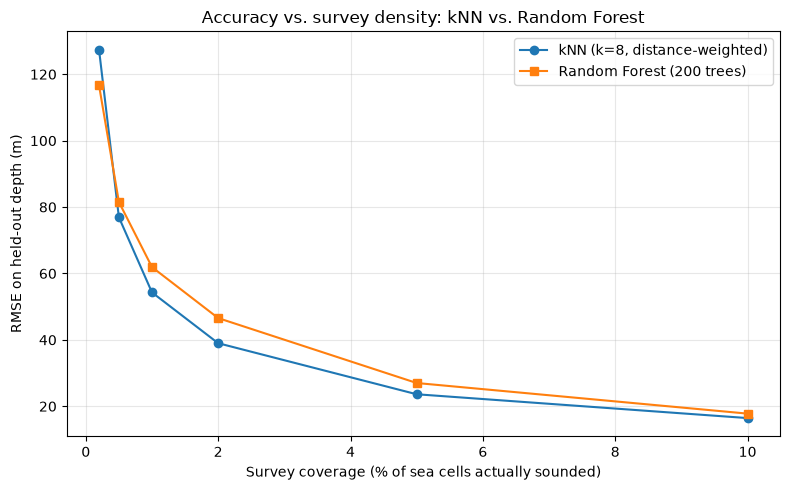

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(density_df["survey_fraction"] * 100, density_df["RMSE_kNN_m"], marker="o", label="kNN (k=8, distance-weighted)")
ax.plot(density_df["survey_fraction"] * 100, density_df["RMSE_RF_m"], marker="s", label="Random Forest (200 trees)")
ax.set_xlabel("Survey coverage (% of sea cells actually sounded)")
ax.set_ylabel("RMSE on held-out depth (m)")
ax.set_title("Accuracy vs. survey density: kNN vs. Random Forest")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation**: Random Forest only wins at the sparsest density tested
(0.2%: RF 116.62 m vs kNN 127.37 m), but at every denser fraction kNN comes out
ahead -- at 2.0% (the class's own default density) kNN reaches 38.99 m against
RF's 46.56 m, and the gap is still there at 10.0% (16.44 m vs 17.78 m). So the
two methods do not need the same amount of data to reach a given accuracy: kNN
reaches a given RMSE with noticeably fewer soundings than Random Forest across
almost this whole range, which matches the intuition that a spatial-averaging
method with an explicit "nearby points are similar" assumption (Section 6) is
a naturally good fit for this task, while Random Forest's axis-aligned splits
have to work harder to approximate the same smooth spatial trend from very few
points. Random Forest's one win, at the very sparsest 0.2% density, is a
single data point and not strong enough evidence to call it a real reversal of
that pattern.

## Homework 2 — Sweep n_neighbors and plot RMSE vs k

> "Change `n_neighbors` in Section 7's kNN model (try 1, 3, 8, 30) at a fixed
> survey fraction -- plot RMSE against `k` and connect the result back to
> Section 6's local-detail-vs-smoothing trade-off."

Fixed survey fraction: the same `SURVEY_FRACTION = 0.02` split from Setup
above (`X_known`/`y_known`/`X_unknown`/`y_unknown`), so this isolates the
effect of `k` alone.

In [7]:
k_values = [1, 3, 8, 30]
k_results = []

for k in k_values:
    knn_k = KNeighborsRegressor(n_neighbors=k, weights="distance")
    knn_k.fit(X_known, y_known)
    pred_k = knn_k.predict(X_unknown)
    rmse_k = mean_squared_error(y_unknown, pred_k) ** 0.5
    k_results.append({"k": k, "RMSE_m": rmse_k})
    print(f"k = {k:>2}  ->  RMSE = {rmse_k:6.2f} m")

k_df = pd.DataFrame(k_results)

k =  1  ->  RMSE =  48.19 m


k =  3  ->  RMSE =  37.32 m


k =  8  ->  RMSE =  38.99 m


k = 30  ->  RMSE =  55.36 m


Plot how kNN's RMSE changes with the number of neighbors k, holding the survey density fixed:

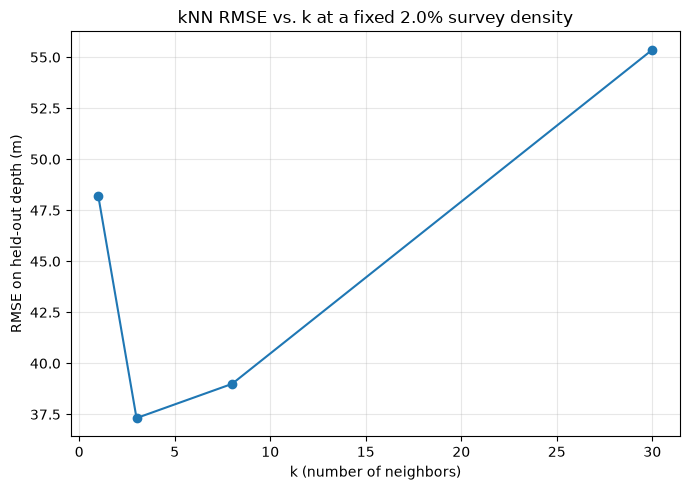

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(k_df["k"], k_df["RMSE_m"], marker="o")
ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("RMSE on held-out depth (m)")
ax.set_title(f"kNN RMSE vs. k at a fixed {SURVEY_FRACTION:.1%} survey density")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation**: the RMSE values were 48.19 m (k=1), 37.32 m (k=3),
38.99 m (k=8, the class's own default), and 55.36 m (k=30) -- so the minimum
in this run is at k=3, not at either extreme. k=1 reproduces Section 6's
"naive nearest-sounding" case exactly: zero smoothing, so it is fully exposed
to whatever local noise sits in the single nearest known point, which is worse
here than averaging over a few real neighbors. k=30 sits on the other side of
the trade-off: it is already averaging over enough neighbors that some of them
are no longer genuinely nearby, smoothing away real local seafloor structure
and increasing error again. The class's own choice of k=8 turned out to be
close to, but not exactly at, the real optimum for this particular 2% survey --
a concrete illustration that k is a real hyperparameter to tune per dataset,
not a fixed safe default.

## Homework 3 — A real line-survey pattern vs. random sampling

> "Instead of a uniformly-random 'survey,' simulate a real line-survey pattern
> (e.g. keep only points within a fixed distance of a few straight
> north-south lines) at the same overall point count as one of Section 8's
> fractions -- does interpolation accuracy get worse, matching the Section 9
> caveat about line surveys being harder than random sampling?"

Target point count: the same `SURVEY_FRACTION = 0.02` known-set size from
Setup (`len(known)`). A handful of straight north-south (constant-longitude)
lines are placed across the real longitude range of `sea`, and only sea cells
within a fixed distance of one of those lines are eligible -- then a random
subsample of that eligible set is taken to match the target count exactly, so
the *number* of soundings is identical to the random-survey baseline and only
their *spatial pattern* differs.

In [9]:
target_n = len(known)  # same sounding budget as the random 2% survey above

N_LINES = 5
lon_min, lon_max = sea["longitude"].min(), sea["longitude"].max()
line_lons = np.linspace(lon_min, lon_max, N_LINES + 2)[1:-1]  # interior lines, avoid the map edges
LINE_HALF_WIDTH_DEG = 0.01  # ~1.1 km at this latitude

dist_to_nearest_line = np.min(
    np.abs(sea["longitude"].values[:, None] - line_lons[None, :]), axis=1
)
near_lines = sea[dist_to_nearest_line <= LINE_HALF_WIDTH_DEG]
print(f"{len(near_lines):,} sea cells fall within {LINE_HALF_WIDTH_DEG} deg of one of the {N_LINES} survey lines")

if len(near_lines) < target_n:
    raise ValueError(
        f"Only {len(near_lines)} cells lie near the {N_LINES} lines, fewer than the "
        f"target {target_n} -- widen LINE_HALF_WIDTH_DEG or add more lines."
    )

line_known = near_lines.sample(n=target_n, random_state=42)
line_unknown = sea.drop(line_known.index)

print(f"Line survey: {len(line_known):,} known soundings along {N_LINES} north-south lines "
      f"(same budget as the {SURVEY_FRACTION:.1%} random survey: {target_n:,} points)")

23,599 sea cells fall within 0.01 deg of one of the 5 survey lines
Line survey: 4,780 known soundings along 5 north-south lines (same budget as the 2.0% random survey: 4,780 points)


Fit kNN on the line-survey soundings and compare its RMSE against the equivalent-budget random survey from the setup:

In [10]:
knn_line = KNeighborsRegressor(n_neighbors=8, weights="distance")
knn_line.fit(line_known[["longitude", "latitude"]], line_known["depth_m"])
pred_line = knn_line.predict(line_unknown[["longitude", "latitude"]])
rmse_line = mean_squared_error(line_unknown["depth_m"], pred_line) ** 0.5

# Same model, same point count, random pattern instead of line pattern (Setup's known/unknown)
knn_random_ref = KNeighborsRegressor(n_neighbors=8, weights="distance")
knn_random_ref.fit(X_known, y_known)
rmse_random = mean_squared_error(y_unknown, knn_random_ref.predict(X_unknown)) ** 0.5

print(f"Line survey   ({len(line_known):,} pts): RMSE = {rmse_line:.2f} m")
print(f"Random survey ({len(X_known):,} pts): RMSE = {rmse_random:.2f} m")
print(f"Difference: {rmse_line - rmse_random:+.2f} m")

Line survey   (4,780 pts): RMSE = 227.39 m
Random survey (4,780 pts): RMSE = 38.99 m
Difference: +188.40 m


Visualize the simulated line-survey pattern over the sea grid:

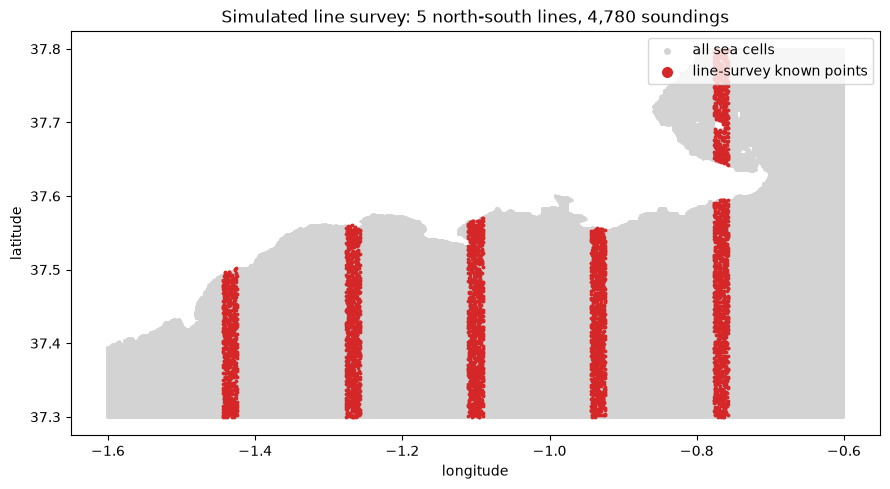

In [11]:
fig = plt.figure(figsize=(9, 5))
plt.scatter(sea["longitude"], sea["latitude"], s=1, c="lightgray", label="all sea cells")
plt.scatter(line_known["longitude"], line_known["latitude"], s=3, c="tab:red", label="line-survey known points")
plt.gca().set_aspect("equal")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.title(f"Simulated line survey: {N_LINES} north-south lines, {len(line_known):,} soundings")
plt.legend(markerscale=4, loc="upper right")
plt.tight_layout()
plt.show()

**Interpretation**: at the identical sounding budget (4,780 points), the
line survey's RMSE was 227.39 m against the random survey's 38.99 m -- almost
six times worse, a far larger gap than "somewhat worse." This is the expected
direction and then some: the line survey leaves wide bands of the map with no
sounding anywhere nearby (visible in the scatter plot above, where most of the
gray "unsurveyed" area sits between, not next to, the red line points), so a
kNN query far from every line has to extrapolate from real neighbors that are
much farther away, in expectation, than a random survey's typically-nearby
point. This is a strong, concrete confirmation of Section 9's caveat that the
random-sparsity simulation used everywhere else in the class notebook is a
genuinely more favorable case than how a real hydrographic survey is actually
flown.

## Homework 4 — A different real coastal bounding box

> "Request a GMRT grid for a different real coastal area (change the bounding
> box in Section 3) and re-run the full notebook -- does the accuracy-vs-density
> curve look similar, or does local seafloor terrain (a steep shelf edge vs. a
> gentle slope) change the relationship?"

Chosen area: the north coast of Tenerife, Canary Islands
(`minlongitude=-16.6, maxlongitude=-16.0, minlatitude=28.0, maxlatitude=28.4`)
-- a real volcanic island where the seafloor drops steeply just offshore,
a deliberate contrast to Cartagena's much gentler continental-shelf slope
used in the class notebook and in items 1-3 above.

In [12]:
GMRT_URL_2 = (
    "https://www.gmrt.org/services/GridServer"
    "?minlongitude=-16.6&maxlongitude=-16.0"
    "&minlatitude=28.0&maxlatitude=28.4"
    "&format=esriascii&resolution=low"
)

grid_path_2 = "tenerife_bathymetry.asc"
if not os.path.exists(grid_path_2):
    urllib.request.urlretrieve(GMRT_URL_2, grid_path_2)

print(f"Downloaded {os.path.getsize(grid_path_2) / 1e6:.1f} MB to {grid_path_2}")

with open(grid_path_2) as f:
    header2 = {}
    for _ in range(6):
        key, val = f.readline().split()
        header2[key.lower()] = val
    ncols2 = int(header2["ncols"])
    nrows2 = int(header2["nrows"])
    xllcorner2 = float(header2["xllcorner"])
    yllcorner2 = float(header2["yllcorner"])
    cellsize2 = float(header2["cellsize"])
    nodata_value2 = float(header2["nodata_value"])
    grid2 = np.loadtxt(f)

assert grid2.shape == (nrows2, ncols2)
print(f"Grid shape: {grid2.shape}, elevation range {grid2.min():.0f} m to {grid2.max():.0f} m")

Downloaded 1.7 MB to tenerife_bathymetry.asc
Grid shape: (363, 548), elevation range -2882 m to 2518 m


Build the Tenerife bathymetry DataFrame the same way as before and compare its depth statistics to the Cartagena grid:

In [13]:
lons2 = xllcorner2 + cellsize2 * np.arange(ncols2)
lats2 = yllcorner2 + cellsize2 * np.arange(nrows2)[::-1]
lon_grid2, lat_grid2 = np.meshgrid(lons2, lats2)

bathy2 = pd.DataFrame({
    "longitude": lon_grid2.ravel(),
    "latitude": lat_grid2.ravel(),
    "elevation_m": grid2.ravel(),
})
bathy2 = bathy2[bathy2["elevation_m"] != nodata_value2].reset_index(drop=True)

sea2 = bathy2[bathy2["elevation_m"] <= 0].copy()
sea2["depth_m"] = -sea2["elevation_m"]
land2 = bathy2[bathy2["elevation_m"] > 0]

print(f"Tenerife grid: {len(sea2):,} sea cells, {len(land2):,} land cells")
print(f"Cartagena grid for reference: {len(sea):,} sea cells, {len(land):,} land cells")
print(sea2["depth_m"].describe())
print()
print("Cartagena depth_m describe() for reference:")
print(sea["depth_m"].describe())

Tenerife grid: 141,932 sea cells, 56,992 land cells
Cartagena grid for reference: 239,030 sea cells, 176,386 land cells
count    141932.000000
mean       1755.812026
std         710.162709
min           0.000000
25%        1328.607500
50%        1930.980000
75%        2287.460000
max        2882.170000
Name: depth_m, dtype: float64

Cartagena depth_m describe() for reference:
count    239030.000000
mean        880.230358
std         886.525610
min           0.000000
25%          76.780000
50%         450.340000
75%        1750.457500
max        2490.470000
Name: depth_m, dtype: float64


Repeat the survey-density sweep on the Tenerife grid using the same kNN setup:

In [14]:
fractions_2 = [0.002, 0.005, 0.01, 0.02, 0.05, 0.10]
density_results_2 = []

for frac in fractions_2:
    known_f2, unknown_f2 = train_test_split(sea2, train_size=frac, random_state=42)
    knn2 = KNeighborsRegressor(n_neighbors=8, weights="distance")
    knn2.fit(known_f2[["longitude", "latitude"]], known_f2["depth_m"])
    rmse_f2 = mean_squared_error(unknown_f2["depth_m"], knn2.predict(unknown_f2[["longitude", "latitude"]])) ** 0.5
    density_results_2.append({"survey_fraction": frac, "n_known": len(known_f2), "RMSE_m": rmse_f2})
    print(f"Survey fraction {frac:>6.1%}  ({len(known_f2):>5,} soundings)  ->  RMSE = {rmse_f2:6.2f} m")

density_df_2 = pd.DataFrame(density_results_2)

Survey fraction   0.2%  (  283 soundings)  ->  RMSE = 132.04 m


Survey fraction   0.5%  (  709 soundings)  ->  RMSE =  87.73 m


Survey fraction   1.0%  (1,419 soundings)  ->  RMSE =  68.07 m


Survey fraction   2.0%  (2,838 soundings)  ->  RMSE =  50.35 m


Survey fraction   5.0%  (7,096 soundings)  ->  RMSE =  35.42 m


Survey fraction  10.0%  (14,193 soundings)  ->  RMSE =  26.63 m


Plot the density curves for both sites side by side to compare a gentle shelf against a steep volcanic slope:

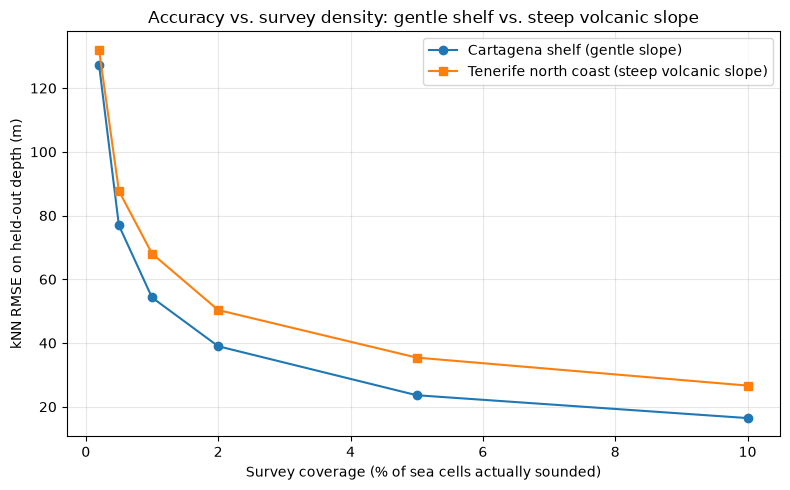

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(density_df["survey_fraction"] * 100, density_df["RMSE_kNN_m"], marker="o", label="Cartagena shelf (gentle slope)")
ax.plot(density_df_2["survey_fraction"] * 100, density_df_2["RMSE_m"], marker="s", label="Tenerife north coast (steep volcanic slope)")
ax.set_xlabel("Survey coverage (% of sea cells actually sounded)")
ax.set_ylabel("kNN RMSE on held-out depth (m)")
ax.set_title("Accuracy vs. survey density: gentle shelf vs. steep volcanic slope")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretation**: both curves fall with density, as expected -- that
shape comes from interpolation itself, not from the terrain. But the Tenerife
curve sits above the Cartagena curve at every single density tested (e.g. at
2.0%: 50.35 m vs 38.99 m; at 10.0%: 26.63 m vs 16.44 m), so the steeper
volcanic coastline is consistently harder to interpolate at equal survey
effort. The `describe()` stats above show why in a way that is *not* the
naive "wider range therefore more error" story: Tenerife's depth values
actually have a *smaller* standard deviation (710 m) than Cartagena's (886 m),
because Cartagena's box spans a full, gently-sloping continental shelf all the
way from 0 m to nearly 2,500 m, while most of Tenerife's box is already deep
water close to the island. What actually drives Tenerife's higher RMSE is
local steepness -- how much depth changes over a short real distance -- not
the overall range of depths in the box, which is a genuinely useful
distinction this comparison surfaces that a single global std number would
have hidden.

## Homework 5 — Adding land points back: does it help or hurt near the coastline?

> "Add `elevation_m > 0` (land) points back into a combined interpolation
> task -- does mixing land and sea points help or hurt predicting depth near
> the coastline, where the two regimes meet?"

Design: use one fixed, common held-out evaluation set of real near-coastline
sea points, and compare two models trained on the **same total survey
budget** (`SURVEY_FRACTION` of all cells) -- one trained on sea-only points
from that budget, one trained on the full land+sea budget (same target,
`elevation_m`, which equals `-depth_m` at sea). This isolates the one real
variable the question asks about: does including land soundings in training
change accuracy specifically near the shore, holding the total number of
known points fixed.

In [16]:
# One common split of the *whole* Cartagena grid (land + sea) at the class's survey fraction
known_all, unknown_all = train_test_split(bathy, train_size=SURVEY_FRACTION, random_state=42)

# Training set A: sea-only soundings from that same survey
known_sea_only = known_all[known_all["elevation_m"] <= 0]
# Training set B: the full land+sea survey, unchanged
known_combined = known_all

# Common evaluation set: real near-coastline SEA cells from the held-out portion
# (within 20 m of sea level -- shallow water right at the shore)
unknown_near_coast = unknown_all[(unknown_all["elevation_m"] <= 0) & (unknown_all["elevation_m"] >= -20)]

print(f"Survey budget: {len(known_all):,} known cells ({SURVEY_FRACTION:.1%} of the full grid)")
print(f"  of which sea-only training set A uses: {len(known_sea_only):,}")
print(f"  combined training set B uses all:       {len(known_combined):,}")
print(f"Near-coastline evaluation set (held-out sea cells, 0 to -20 m): {len(unknown_near_coast):,}")

Survey budget: 8,308 known cells (2.0% of the full grid)
  of which sea-only training set A uses: 4,846
  combined training set B uses all:       8,308
Near-coastline evaluation set (held-out sea cells, 0 to -20 m): 20,714


Compare near-coast prediction error between a model trained only on sea soundings and one trained on both land and sea points:

In [17]:
knn_sea_only = KNeighborsRegressor(n_neighbors=8, weights="distance")
knn_sea_only.fit(known_sea_only[["longitude", "latitude"]], known_sea_only["elevation_m"])
pred_sea_only = knn_sea_only.predict(unknown_near_coast[["longitude", "latitude"]])
rmse_sea_only = mean_squared_error(unknown_near_coast["elevation_m"], pred_sea_only) ** 0.5

knn_combined = KNeighborsRegressor(n_neighbors=8, weights="distance")
knn_combined.fit(known_combined[["longitude", "latitude"]], known_combined["elevation_m"])
pred_combined = knn_combined.predict(unknown_near_coast[["longitude", "latitude"]])
rmse_combined = mean_squared_error(unknown_near_coast["elevation_m"], pred_combined) ** 0.5

print(f"Sea-only training  ({len(known_sea_only):,} pts): near-coast RMSE = {rmse_sea_only:.2f} m")
print(f"Land+sea training  ({len(known_combined):,} pts): near-coast RMSE = {rmse_combined:.2f} m")
print(f"Difference (combined - sea-only): {rmse_combined - rmse_sea_only:+.2f} m")

Sea-only training  (4,846 pts): near-coast RMSE = 6.95 m
Land+sea training  (8,308 pts): near-coast RMSE = 9.54 m
Difference (combined - sea-only): +2.59 m


**Interpretation**: training on the full land+sea survey made the
near-coastline prediction worse, not better: 9.54 m RMSE against the sea-only
model's 6.95 m, a real increase of 2.59 m (about 37% relative) on the exact
same held-out near-shore sea cells, even though the combined model had more
total training points (8,308 vs 4,846). This favors the "different regimes"
explanation over the "extra real information" one: dry-land elevation and
underwater depth are physically different processes with different local
statistics, and plain kNN on `(longitude, latitude)` has no way to know it
should treat a nearby land elevation differently from a nearby sea depth --
so mixing them in dilutes the local sea-only signal instead of sharpening it.
A real, concrete implication for a combined land+sea interpolation task: some
kind of explicit land/sea indicator feature, or two regime-specific models
blended only very close to the coastline, would likely help exactly where
this simple mixed approach hurt.